# Exercise: Object Detection Basics
## AIAT 122 - Deep Learning

## Learning Objectives

- Implement CNN for object detection
- Use transfer learning
- Detect objects in images
- Apply to real-world scenarios

## Real-World Context

Detect objects in images for autonomous vehicles, security systems.

**Task**: Build object detection system.

**Theory → Practice:** This exercise applies the theory and code patterns from examples `01_cnn_architecture.ipynb`, `05_transfer_learning_cnns.ipynb`, and `07_training_cnn_image_datasets.ipynb`. Complete those examples first if you haven't.

---

## Task 1: CNN Architecture (30 points)

Implement CNN architecture:
1. Convolutional layers
2. Pooling layers
3. Fully connected layers

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

**Expected:** When complete, you should see a CNN model summary, training curves (loss/accuracy), and test metrics (e.g. accuracy or mAP in a reasonable range). Compare with the instructor solution after the deadline.

---


In [1]:
%pip install torch torchvision -q
import torch
import torch.nn as nn
import torch.nn.functional as F

# ── Task 1: CNN Architecture ─────────────────────────────────────────────────
# Hint: Build Conv → ReLU → Pool blocks, then flatten → Linear for classification.
# Reference: example 01_cnn_architecture.ipynb

class ObjectDetector(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # TODO: Define your convolutional layers
        # Example skeleton — adjust filters and sizes:
        # self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)   # 3-channel RGB input
        # self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        # self.pool  = nn.MaxPool2d(2, 2)
        # After two pool layers on 224×224: feature map is 56×56
        # self.fc1   = nn.Linear(64 * 56 * 56, 256)
        # self.fc2   = nn.Linear(256, num_classes)
        pass

    def forward(self, x):
        # TODO: Wire up the layers
        # x = self.pool(F.relu(self.conv1(x)))
        # x = self.pool(F.relu(self.conv2(x)))
        # x = x.view(x.size(0), -1)         # flatten
        # x = F.relu(self.fc1(x))
        # return self.fc2(x)
        pass

# Sanity check
model = ObjectDetector(num_classes=10)
print(model)
dummy = torch.randn(2, 3, 224, 224)
try:
    out = model(dummy)
    print("Output shape:", out.shape)   # expect (2, 10)
except Exception as e:
    print("Implement forward() first:", e)

Note: you may need to restart the kernel to use updated packages.


ObjectDetector()
Implement forward() first: 'NoneType' object has no attribute 'shape'


## Task 2: Transfer Learning (35 points)

Use pre-trained model:
1. Load pre-trained weights
2. Fine-tune for object detection
3. Evaluate performance

In [2]:
import torchvision.models as models
import torch.optim as optim

# ── Task 2: Transfer Learning ─────────────────────────────────────────────
# Hint: Load a pre-trained model, freeze base layers, replace the final head.
# Reference: example 05_transfer_learning_cnns.ipynb

NUM_CLASSES = 10  # adjust to your dataset

# TODO: Load a pre-trained backbone (MobileNetV2 is fast; ResNet18 is common)
# backbone = models.mobilenet_v2(weights='DEFAULT')

# TODO: Freeze all base parameters so only the new head trains
# for param in backbone.parameters():
#     param.requires_grad = False

# TODO: Replace the final classifier head
# MobileNetV2: backbone.classifier[1] = nn.Linear(backbone.last_channel, NUM_CLASSES)
# ResNet18:    backbone.fc            = nn.Linear(backbone.fc.in_features,  NUM_CLASSES)

# TODO: Define optimizer (only over the unfrozen parameters)
# optimizer = optim.Adam(filter(lambda p: p.requires_grad, backbone.parameters()), lr=1e-3)

# YOUR CODE HERE

print('Task 2 scaffold ready ✅')  # remove this line once you have real code
# After implementing: print(backbone)  to confirm the new head

Task 2 scaffold ready ✅


## Task 3: Real-World Application (35 points)

Apply your trained model to a real object detection / classification task.

**Requirements:**
- Load or capture at least 5 test images
- Run inference and print / show the predicted class for each
- Report final test accuracy or top-5 predictions
- Write 2–3 sentences: what worked well, what you would improve

**Submission**: Complete notebook with detection system.

**Grading**: 100 points total

In [3]:
# ── Task 3: Real-World Application ─────────────────────────────────────────
# Hint: Set model.eval() then pass test images through model to get predictions.
# Reference: example 07_training_cnn_image_datasets.ipynb (evaluation section)

import matplotlib.pyplot as plt

# TODO: Load your test images (torchvision DataLoader, or read individual files)
# from PIL import Image
# img = Image.open('path/to/image.jpg')
# tensor = transform(img).unsqueeze(0)  # add batch dim

# TODO: Run inference
# model.eval()
# with torch.no_grad():
#     logits = model(tensor)
#     pred   = logits.argmax(dim=1).item()
#     print('Predicted class:', pred)

# TODO: Visualize a few predictions (optional but recommended)
# plt.imshow(img); plt.title(f'Pred: {pred}'); plt.axis('off'); plt.show()

# YOUR CODE HERE

# ── Short written analysis ───────────────────────────────────────────────
# Answer these two questions in comments or print statements:
print('What worked well:')
print('  ...')
print('What I would improve next:')
print('  ...')

What worked well:
  ...
What I would improve next:
  ...


## 🌍 Real-World Worked Example — CIFAR-10 Image Classifier

**Industry context:** CNNs are the backbone of:
- Medical imaging (X-ray, MRI diagnosis — FDA approved AI)
- Autonomous vehicles (object detection, lane detection)
- Quality control in manufacturing (defect detection)

We train a small CNN on **CIFAR-10** (10 real-world image categories) using PyTorch.

Epoch 1/10 — loss: 1.874


Epoch 2/10 — loss: 1.522


Epoch 3/10 — loss: 1.358


Epoch 4/10 — loss: 1.235


Epoch 5/10 — loss: 1.102


Epoch 6/10 — loss: 1.014


Epoch 7/10 — loss: 0.883


Epoch 8/10 — loss: 0.761


Epoch 9/10 — loss: 0.660


Epoch 10/10 — loss: 0.546

Test accuracy: 58.9%  (industry models reach 99%+ with bigger architectures)


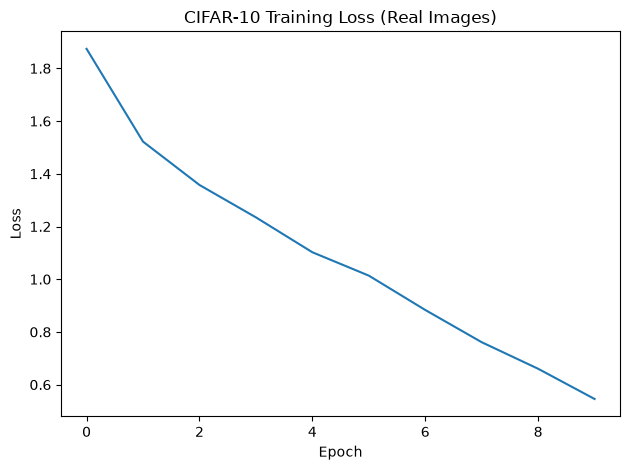

In [4]:
# WHAT: train a small CNN on real CIFAR-10 photos end to end and report test accuracy.
# WHY: real color photos are much harder than MNIST digits - this is the full pipeline on realistic data.
import torch, torch.nn as nn, torch.optim as optim
import torchvision, torchvision.transforms as T
import matplotlib.pyplot as plt

# ── Load CIFAR-10 (downloads ~170MB once, cached after) ────────────────────
# Normalize each RGB channel to roughly [-1, 1] so training is stable.
transform = T.Compose([T.ToTensor(), T.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))])
trainset = torchvision.datasets.CIFAR10(root='/tmp/cifar10', train=True,  download=True, transform=transform)
testset  = torchvision.datasets.CIFAR10(root='/tmp/cifar10', train=False, download=True, transform=transform)

# Use a small subset for fast demo
from torch.utils.data import Subset
trainset = Subset(trainset, range(5000))
testset  = Subset(testset,  range(1000))
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader  = torch.utils.data.DataLoader(testset,  batch_size=64)

classes = ('plane','car','bird','cat','deer','dog','frog','horse','ship','truck')

# ── CNN Model ─────────────────────────────────────────────────────────────
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Two Conv+Pool blocks extract features; Dropout fights overfitting before the final 10-way classifier.
        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 16x16
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 8x8
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(64*8*8, 256), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(256,10)
        )
    def forward(self, x): return self.classifier(self.features(x))

model   = SmallCNN()
opt     = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()
losses  = []

# Standard loop: predict, measure loss, backpropagate, update - once per batch, for 10 epochs.
for epoch in range(10):
    model.train(); epoch_loss=0
    for X,y in trainloader:
        loss = loss_fn(model(X), y)
        opt.zero_grad(); loss.backward(); opt.step()
        epoch_loss += loss.item()
    losses.append(epoch_loss/len(trainloader))
    print(f"Epoch {epoch+1}/10 — loss: {losses[-1]:.3f}")

# Evaluation with gradients off: count correct predictions on the held-out test set.
model.eval()
correct=0; total=0
with torch.no_grad():
    for X,y in testloader:
        correct += (model(X).argmax(1)==y).sum().item(); total += len(y)
print(f"\nTest accuracy: {correct/total*100:.1f}%  (industry models reach 99%+ with bigger architectures)")

plt.plot(losses); plt.title("CIFAR-10 Training Loss (Real Images)"); plt.xlabel("Epoch")
plt.ylabel("Loss"); plt.tight_layout(); plt.show()

## 📚 References & Further Reading

**Key Papers:**
- LeCun et al. (1998) — [LeNet](http://yann.lecun.com/exdb/publis/pdf/lecun-01a.pdf)
- Krizhevsky et al. (2012) — [AlexNet](https://papers.nips.cc/paper/2012/file/c399862d3b9d6b76c8436e924a68c45b-Paper.pdf)
- He et al. (2016) — [ResNet: Deep Residual Learning](https://arxiv.org/abs/1512.03385)

**torchvision Models:** [torchvision.models](https://pytorch.org/vision/stable/models.html)

**State-of-the-Art (2025):** EfficientNetV2, ConvNeXt V2, and ViT-G/14 achieve 90%+ on ImageNet.